In [88]:
import pandas as pd
file_path1="folder/household_power_consumption.txt"
file_path2="combined.csv"
file_path3="combined_numeric.csv"

In [89]:
with open (file_path1,'r') as f:
    print(f.readline())
    print("read successful")

Date;Time;Global_active_power;Global_reactive_power;Voltage;Global_intensity;Sub_metering_1;Sub_metering_2;Sub_metering_3

read successful


In [90]:
df = pd.read_csv(file_path1,sep=";")
print(df.head())

         Date      Time Global_active_power Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00               4.216                 0.418  234.840   
1  16/12/2006  17:25:00               5.360                 0.436  233.630   
2  16/12/2006  17:26:00               5.374                 0.498  233.290   
3  16/12/2006  17:27:00               5.388                 0.502  233.740   
4  16/12/2006  17:28:00               3.666                 0.528  235.680   

  Global_intensity Sub_metering_1 Sub_metering_2  Sub_metering_3  
0           18.400          0.000          1.000            17.0  
1           23.000          0.000          1.000            16.0  
2           23.000          0.000          2.000            17.0  
3           23.000          0.000          1.000            17.0  
4           15.800          0.000          1.000            17.0  


C:\Users\moksh\AppData\Local\Temp\ipykernel_30780\336500334.py:1: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path1,sep=";")


In [91]:
# Merge  Date and time into one
df["Datetime"]= pd.to_datetime(df["Date"]+" "+df["Time"],format="%d/%m/%Y %H:%M:%S")
df.set_index("Datetime", inplace=True)
df.drop(columns=["Date","Time"],inplace=True)
df.to_csv("combined.csv")

In [92]:
#object to float64
df=pd.read_csv(file_path2,index_col=0,parse_dates=True)
cols=df.columns
df[cols]=df[cols].apply(pd.to_numeric,errors="coerce")
df.to_csv(file_path3)

C:\Users\moksh\AppData\Local\Temp\ipykernel_30780\2815619189.py:2: DtypeWarning: Columns (1,2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(file_path2,index_col=0,parse_dates=True)


In [93]:
#verify the conversion
df=pd.read_csv(file_path3,index_col=0,parse_dates=True)
print(df.dtypes)

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object


In [94]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv(file_path3,index_col=0,parse_dates=True)
print(df.head())
print(df.info())
df.shape

                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:24:00              18.4             0.0             1.0   
2006-12-16 17:25:00              23.0             0.0             1.0   
2006-12-16 17:26:00              23.0             0.0             2.0   
2006-12-16 17:27:00              23.0             0.0             1.0   
2006-12-16 17:28:00          

(2075259, 7)

In [95]:
#calculating missing values
missing_values = df.isna().sum()
print(missing_values)
percentage = missing_values/len(df)
print(percentage)

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64
Global_active_power      0.012518
Global_reactive_power    0.012518
Voltage                  0.012518
Global_intensity         0.012518
Sub_metering_1           0.012518
Sub_metering_2           0.012518
Sub_metering_3           0.012518
dtype: float64


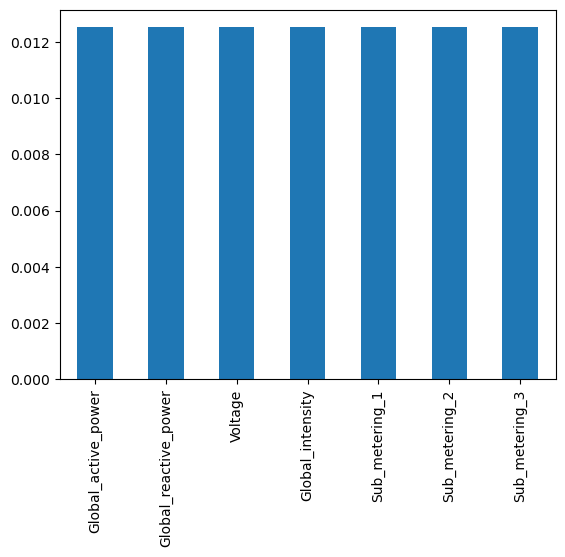

In [96]:
#visualizing missing values
percentage.plot(kind='bar')
plt.show()

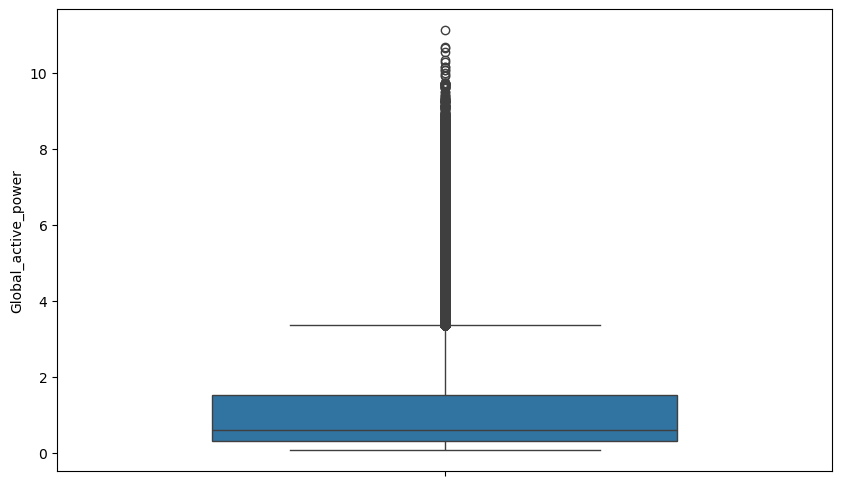

In [97]:
#see outliers for evey columns as follows
plt.figure(figsize=(10,6))
sns.boxplot(data=df["Global_active_power"],widths=0.6)
plt.show()

In [98]:
#printing specific dates rows
dec2006=df.loc["2006-12"]
nov2009=df.loc["2009-11"]

subset=pd.concat([dec2006,nov2009])
print(subset)
subset.shape

                     Global_active_power  Global_reactive_power  Voltage  \
Datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666                  0.528   235.68   
...                                  ...                    ...      ...   
2009-11-30 23:55:00                0.312                  0.000   244.62   
2009-11-30 23:56:00                0.312                  0.000   244.68   
2009-11-30 23:57:00                0.312                  0.000   245.15   
2009-11-30 23:58:00                0.362                  0.000   244.32   
2009-11-30 23:59:00                0.420                  0.132   243.69   

           

(65196, 7)

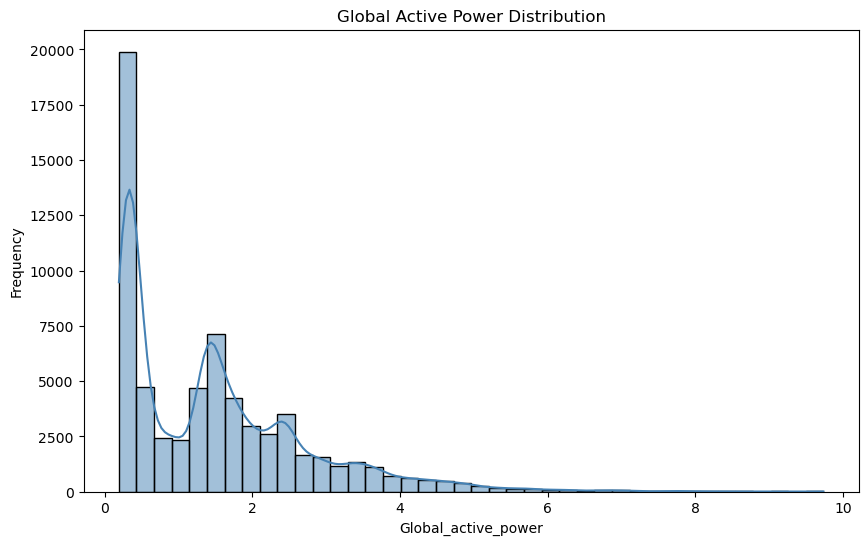

1.3366130800165796
right Skewed


In [99]:
plt.figure(figsize=(10,6))
sns.histplot(
    data=subset,
    x=subset["Global_active_power"],
    bins=40,
    kde=True,
    color="steelblue"
)
plt.title("Global Active Power Distribution")
plt.xlabel("Global_active_power")
plt.ylabel("Frequency")

plt.show()

skew=subset["Global_active_power"].skew()
print(skew)
if(skew>0):
    print("right Skewed")
else:
    print("left Skewed")    

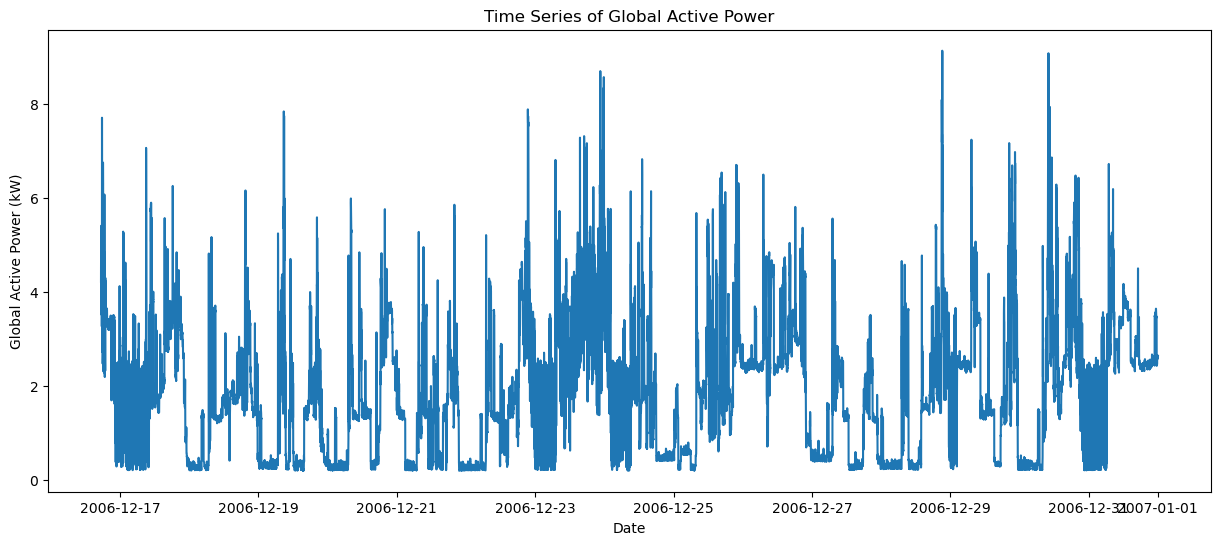

In [100]:
#Visualization of december 2006 for better interpretation
plt.figure(figsize=(15,6))

plt.plot(
    dec2006.index,
    dec2006["Global_active_power"]
)

plt.title("Time Series of Global Active Power")
plt.xlabel("Date")
plt.ylabel("Global Active Power (kW)")

plt.show()

c:\Users\moksh\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


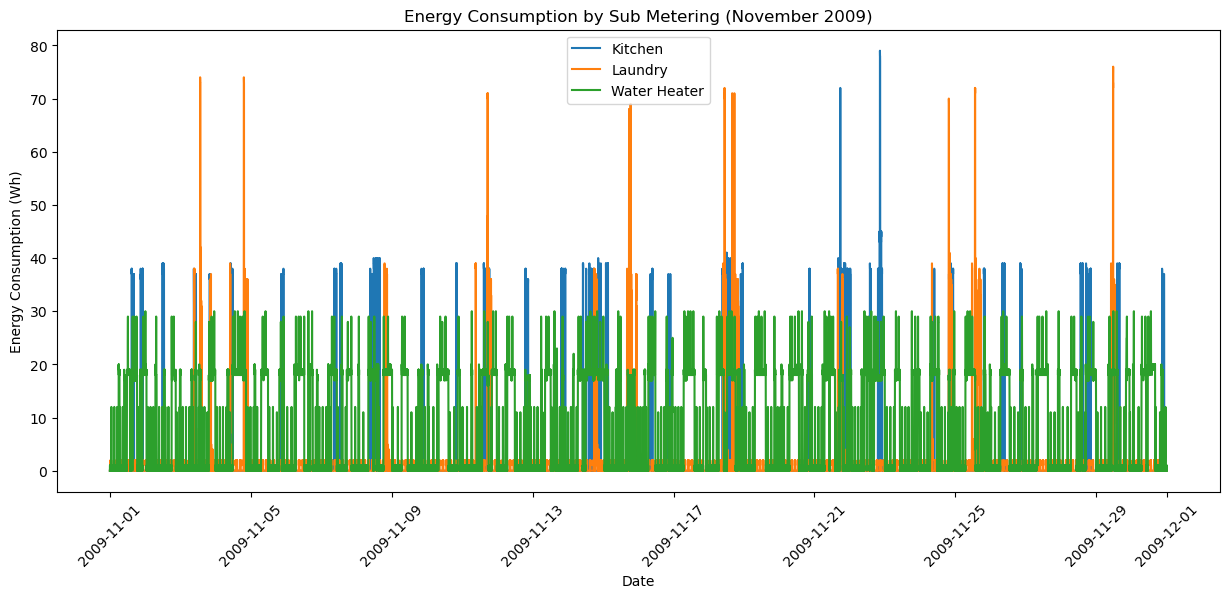

In [101]:
plt.figure(figsize=(15,6))

plt.plot(
    nov2009.index,
    nov2009["Sub_metering_1"],
    label="Kitchen"
)

plt.plot(
    nov2009.index,
    nov2009["Sub_metering_2"],
    label="Laundry"
)

plt.plot(
    nov2009.index,
    nov2009["Sub_metering_3"],
    label="Water Heater"
)

plt.title("Energy Consumption by Sub Metering (November 2009)")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")

plt.legend()

plt.xticks(rotation=45)

plt.show()

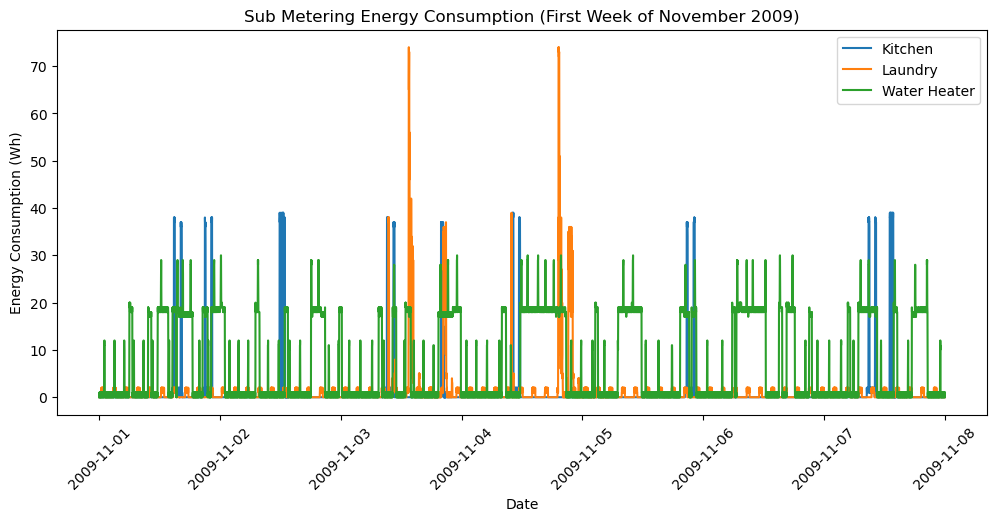

In [102]:
# Data of 1st week of November 
plt.figure(figsize=(12,5))
week_data= df.loc["2009-11-01":"2009-11-07"]
plt.plot(
    week_data.index,
    week_data["Sub_metering_1"],
    label="Kitchen"
)

plt.plot(
    week_data.index,
    week_data["Sub_metering_2"],
    label="Laundry"
)

plt.plot(
    week_data.index,
    week_data["Sub_metering_3"],
    label="Water Heater"
)


plt.title("Sub Metering Energy Consumption (First Week of November 2009)")
plt.xlabel("Date")
plt.ylabel("Energy Consumption (Wh)")

plt.legend()
plt.xticks(rotation=45)

plt.show()

In [103]:
from pathlib import Path
print (Path.cwd())

b:\desktop\sem7\ML_Lab\lab2


In [104]:
# Converting the week data into hourly 
week_hourly = week_data.resample("h").mean()
print(week_hourly.shape)

(168, 7)


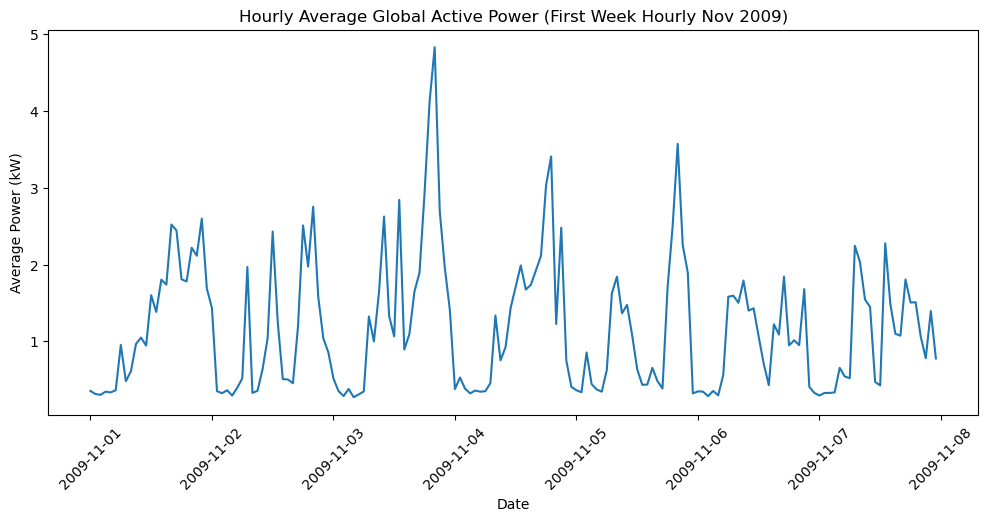

In [106]:
#example
plt.figure(figsize=(12,5))

plt.plot(
    week_hourly.index,
    week_hourly["Global_active_power"]
)

plt.title("Hourly Average Global Active Power (First Week Hourly Nov 2009)")
plt.xlabel("Date")
plt.ylabel("Average Power (kW)")

plt.xticks(rotation=45)

plt.show()

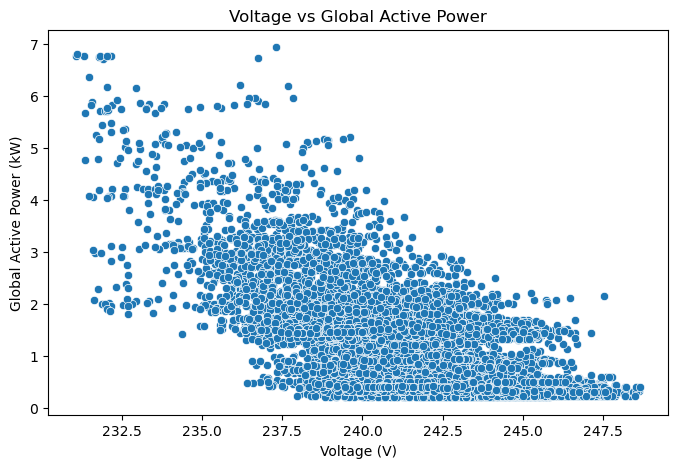

In [ ]:
# ScatterPlot
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=week_data,
    x="Voltage",
    y="Global_active_power"
)

plt.title("Voltage vs Global Active Power")
plt.xlabel("Voltage (V)")
plt.ylabel("Global Active Power (kW)")


plt.savefig(
    "all_plots/scatterplotZ.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

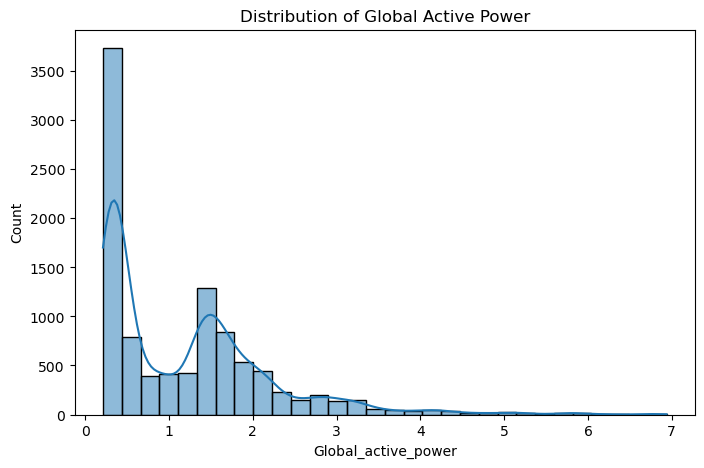

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=week_data,
    x="Global_active_power",
    bins=30,
    kde=True
)

plt.title("Distribution of Global Active Power")

plt.savefig(
    "all_plots/histogramZ.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

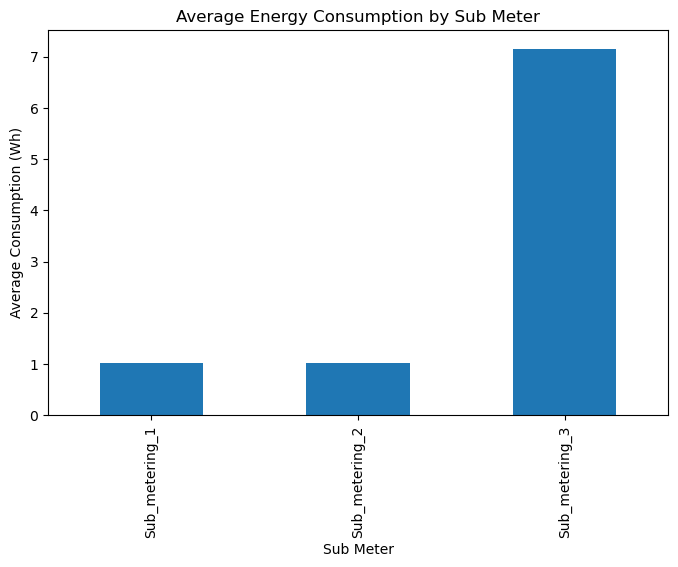

In [ ]:
avg_submeter = week_data[
    [
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
].mean()


plt.figure(figsize=(8,5))

avg_submeter.plot(
    kind="bar"
)

plt.title("Average Energy Consumption by Sub Meter")
plt.xlabel("Sub Meter")
plt.ylabel("Average Consumption (Wh)")


plt.savefig(
    "all_plots/bar_chartZ.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

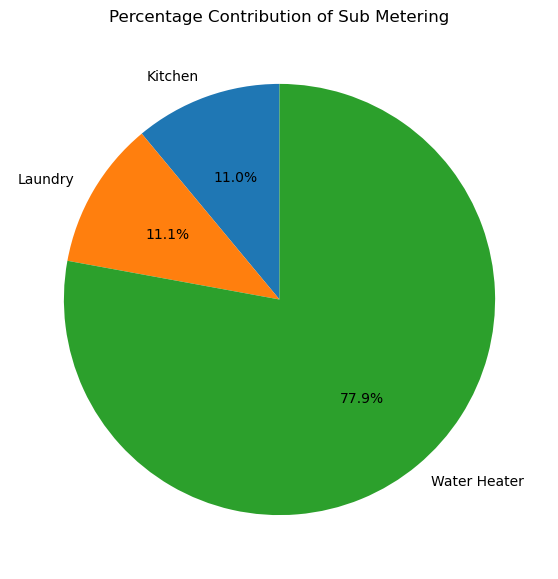

In [ ]:
# Calculate average consumption
submeter_avg = week_hourly[
    [
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
].mean()


plt.figure(figsize=(7,7))

plt.pie(
    submeter_avg,
    labels=[
        "Kitchen",
        "Laundry",
        "Water Heater"
    ],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Contribution of Sub Metering")


plt.savefig(
    "all_plots/pie_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

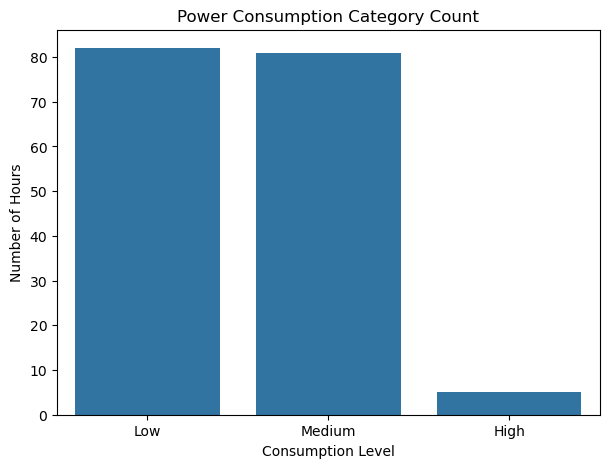

In [ ]:
power_category = pd.cut(
    week_hourly["Global_active_power"],
    bins=[0,1,3,10],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


plt.figure(figsize=(7,5))

sns.countplot(
    x=power_category
)

plt.title("Power Consumption Category Count")
plt.xlabel("Consumption Level")
plt.ylabel("Number of Hours")


plt.savefig(
    "all_plots/count_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

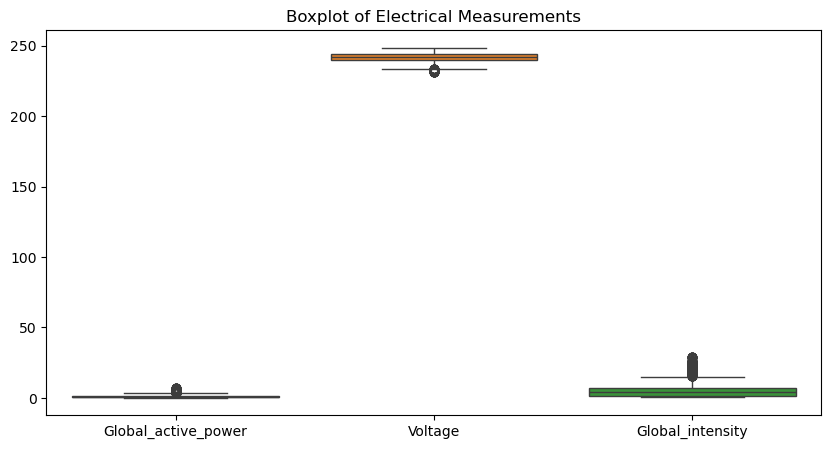

In [ ]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=week_data[
        [
            "Global_active_power",
            "Voltage",
            "Global_intensity"
        ]
    ]
)


plt.title("Boxplot of Electrical Measurements")


plt.savefig(
    "all_plots/boxplotZ.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

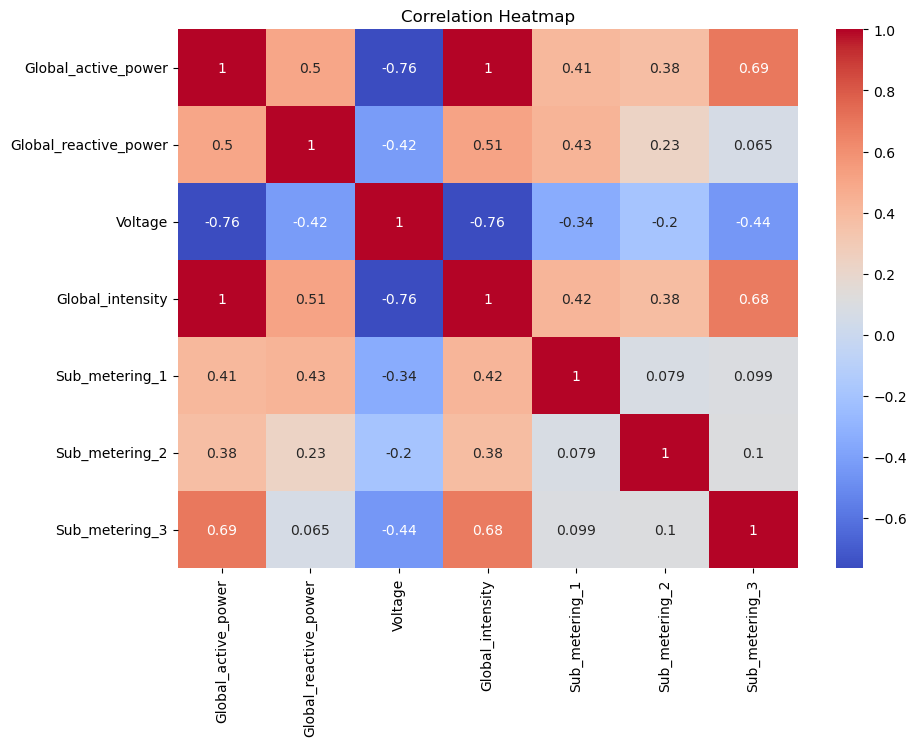

In [ ]:
plt.figure(figsize=(10,7))

correlation = week_hourly.corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")


plt.savefig(
    "all_plots/heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

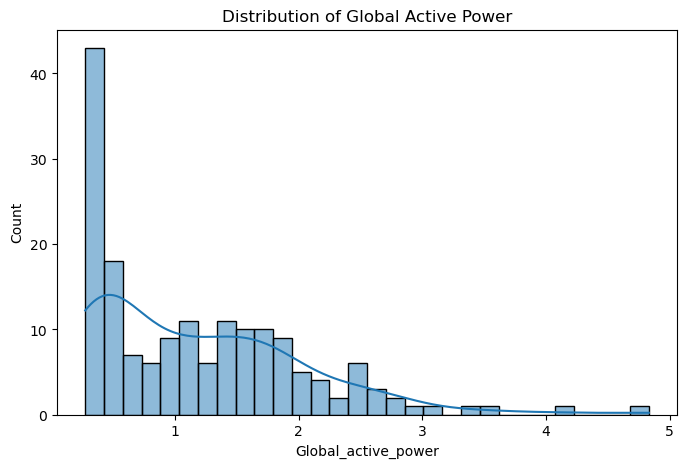

In [ ]:
# Dist Plot is Deprecated in newer seaborn Versions
plt.figure(figsize=(8,5))

sns.histplot(
    week_hourly["Global_active_power"],
    bins=30,
    kde=True
)


plt.title("Distribution of Global Active Power")


plt.savefig(
    "all_plots/distplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

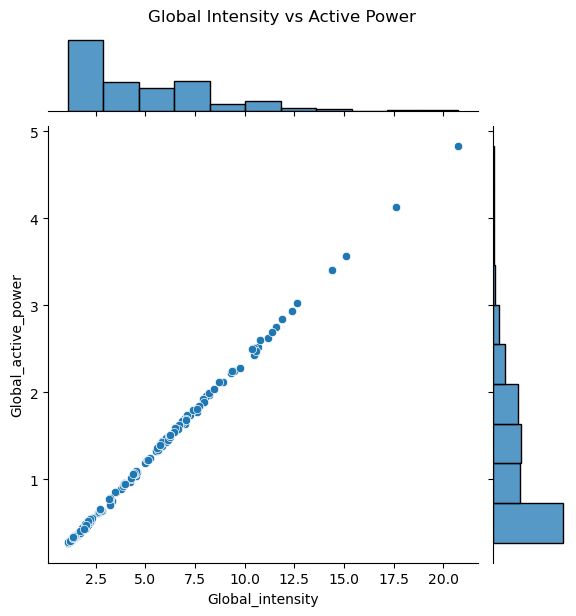

In [ ]:
joint = sns.jointplot(
    data=week_hourly,
    x="Global_intensity",
    y="Global_active_power",
    kind="scatter"
)


joint.fig.suptitle(
    "Global Intensity vs Active Power",
    y=1.02
)


joint.savefig(
    "all_plots/jointplot.png",
    dpi=300,
    bbox_inches="tight"
)